# 14 - Organisation-Wide Skill Gap

Day 3, step 14. The same gaps rolled up across everyone, so the question changes from
"what does this person need?" to "what is this company short of?".

The build notes specify a severity rule: 100+ employees missing a skill is HIGH, 50+
is MEDIUM, otherwise LOW. That rule is implemented exactly as written - and then
tested against this dataset, where it turns out not to work.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from app.services import skill_gap_service as gaps_service
from app.utils.config import (
    PROCESSED_FILES,
    SEVERITY_BANDS,
    SEVERITY_BANDS_RELATIVE,
    gap_severity,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

employees = pd.read_csv(PROCESSED_FILES["attrition"])
gaps = pd.read_csv(PROCESSED_FILES["skill_gaps"])
print(f"{len(gaps):,} gap rows across {len(employees):,} employees")

15,509 gap rows across 1,470 employees


## Rolling up

In [2]:
org = gaps_service.organization_skill_gaps(gaps, total_employees=len(employees))
org.head(20)

,MissingSkill,EmployeesMissing,AvgImportance,DepartmentsAffected,RolesAffected,pct_of_workforce,Severity,SeverityRelative
0,Active Learning,879,3.45,3,9,59.8,HIGH,HIGH
1,Writing,871,3.48,3,9,59.3,HIGH,HIGH
2,Critical Thinking,814,3.66,3,9,55.4,HIGH,HIGH
3,Speaking,801,3.87,3,9,54.5,HIGH,HIGH
4,Active Listening,798,3.91,3,9,54.3,HIGH,HIGH
5,Microsoft Excel,782,4.50,3,9,53.2,HIGH,HIGH
6,Reading Comprehension,779,3.76,3,9,53.0,HIGH,HIGH
7,Microsoft Office,742,4.50,3,9,50.5,HIGH,HIGH
8,Monitoring,712,3.28,3,8,48.4,HIGH,HIGH
9,Microsoft Outlook,559,4.09,3,6,38.0,HIGH,MEDIUM


## The output the dashboard shows

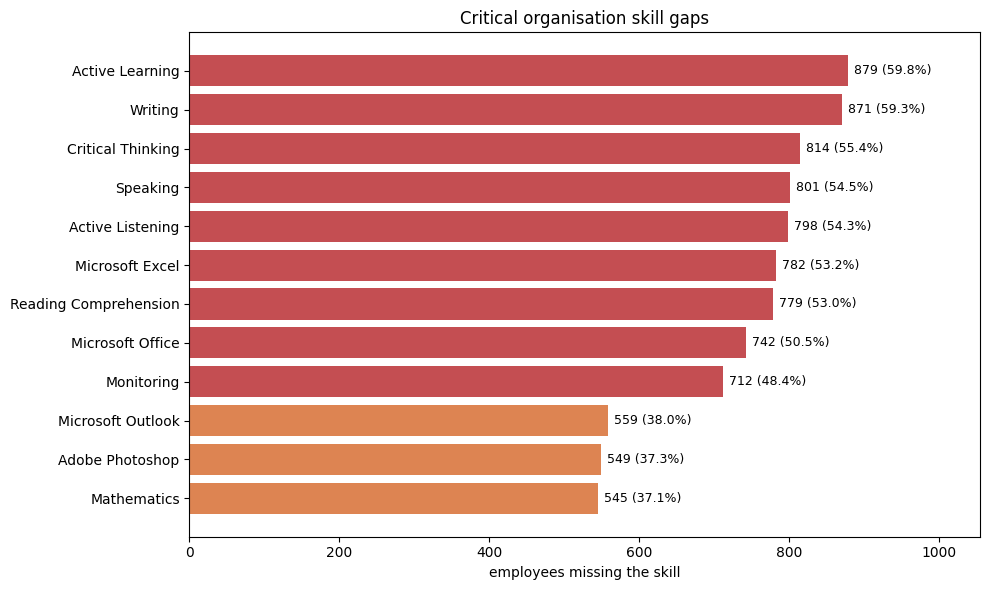

In [3]:
top = org.head(12)
fig, ax = plt.subplots(figsize=(10, 6))
colours = {"HIGH": "#C44E52", "MEDIUM": "#DD8452", "LOW": "#55A868"}
ax.barh(top["MissingSkill"][::-1], top["EmployeesMissing"][::-1],
        color=[colours[s] for s in top["SeverityRelative"][::-1]])
for i, (n, pct) in enumerate(zip(top["EmployeesMissing"][::-1], top["pct_of_workforce"][::-1])):
    ax.text(n + 8, i, f"{n:,} ({pct}%)", va="center", fontsize=9)
ax.set(xlabel="employees missing the skill", title="Critical organisation skill gaps")
ax.set_xlim(0, top["EmployeesMissing"].max() * 1.2)
plt.tight_layout()
plt.show()

## The severity rule as specified, and why it fails here

In [4]:
print(f"Build-notes bands (absolute headcount): {SEVERITY_BANDS}")
print(f"\nDistribution over {len(org)} distinct skills:")
print(org["Severity"].value_counts().to_string())

Build-notes bands (absolute headcount): {'HIGH': 100, 'MEDIUM': 50}

Distribution over 52 distinct skills:
Severity
HIGH      36
MEDIUM    11
LOW        5


**36 of 52 skills come out HIGH.** A severity rating that applies to 69% of the skill
catalogue does not help anyone decide where to spend a training budget - the
dashboard would show a wall of red and the ranking inside it would carry all the
actual information.

The cause is a scale mismatch, not a bug. The 100/50 thresholds were written with a
~2,500-employee organisation in mind. At 1,470 employees, 100 people is under 7% of
the workforce - a low bar for "HIGH". And because every role shares the ten O*NET
essential skills, common gaps naturally reach hundreds of employees.

In [5]:
distribution = org["EmployeesMissing"]
print(f"employees missing a given skill: min {distribution.min()}, "
      f"median {distribution.median():.0f}, max {distribution.max()}")
print(f"skills above the HIGH threshold of {SEVERITY_BANDS['HIGH']}: "
      f"{int((distribution >= SEVERITY_BANDS['HIGH']).sum())} of {len(org)}")

employees missing a given skill: min 29, median 196, max 879
skills above the HIGH threshold of 100: 36 of 52


## The proportional alternative

Expressing severity as a share of the workforce is size-independent: HIGH at 40% of
employees, MEDIUM at 20%. Both columns are carried in the output rather than one
replacing the other, so the spec's rule stays available and the change is a reporting
choice rather than a silent redefinition.

In [6]:
print(f"Relative bands (share of workforce): {SEVERITY_BANDS_RELATIVE}")
print()
print(pd.crosstab(org["Severity"], org["SeverityRelative"],
                  rownames=["spec (absolute)"], colnames=["relative"]))

Relative bands (share of workforce): {'HIGH': 0.4, 'MEDIUM': 0.2}

relative         HIGH  LOW  MEDIUM
spec (absolute)                   
HIGH                9   19       8
LOW                 0    5       0
MEDIUM              0   11       0


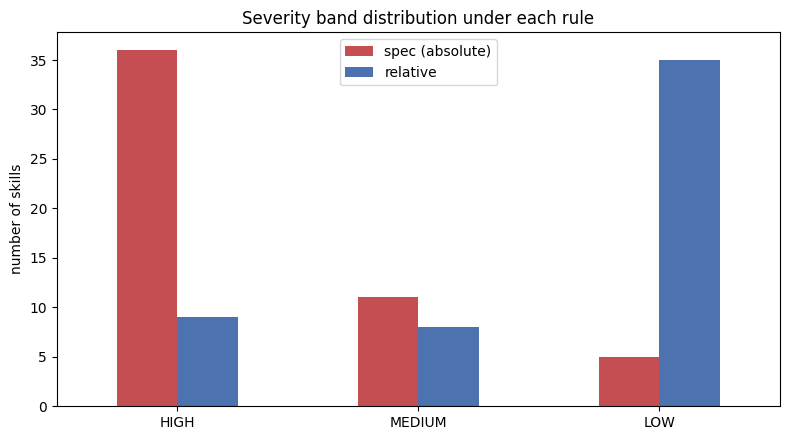

,spec (absolute),relative
HIGH,36,9
MEDIUM,11,8
LOW,5,35


In [7]:
comparison = pd.DataFrame({
    "spec (absolute)": org["Severity"].value_counts(),
    "relative": org["SeverityRelative"].value_counts(),
}).fillna(0).astype(int).reindex(["HIGH", "MEDIUM", "LOW"])

fig, ax = plt.subplots(figsize=(8, 4.5))
comparison.plot(kind="bar", ax=ax, color=["#C44E52", "#4C72B0"])
ax.set(ylabel="number of skills", title="Severity band distribution under each rule")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

comparison

Nine skills come out HIGH under the proportional rule instead of thirty-six. That is
a list a training manager can actually act on.

In [8]:
critical = org[org["SeverityRelative"] == "HIGH"]
print("Critical organisation-wide gaps (>= 40% of the workforce):\n")
print(critical[["MissingSkill", "EmployeesMissing", "pct_of_workforce",
                "AvgImportance", "RolesAffected"]].to_string(index=False))

Critical organisation-wide gaps (>= 40% of the workforce):

         MissingSkill  EmployeesMissing  pct_of_workforce  AvgImportance  RolesAffected
      Active Learning               879              59.8           3.45              9
              Writing               871              59.3           3.48              9
    Critical Thinking               814              55.4           3.66              9
             Speaking               801              54.5           3.87              9
     Active Listening               798              54.3           3.91              9
      Microsoft Excel               782              53.2           4.50              9
Reading Comprehension               779              53.0           3.76              9
     Microsoft Office               742              50.5           4.50              9
           Monitoring               712              48.4           3.28              8


## What these gaps actually are

The critical list is dominated by O*NET *essential* skills - Active Learning,
Writing, Critical Thinking, Speaking, Active Listening - plus the ubiquitous office
tools. That is a meaningful distinction for what to do next.

Essential skills are required by all nine roles, so a shortfall shows up across the
whole workforce and points toward broad, centrally-run training. Software gaps are
concentrated in specific roles and are better handled team by team.

In [9]:
requirements = pd.read_csv(PROCESSED_FILES["role_requirements"])
skill_types = requirements[["SkillName", "SkillType"]].drop_duplicates()
org_typed = org.merge(skill_types, left_on="MissingSkill", right_on="SkillName", how="left")

print(org_typed.groupby(["SkillType", "SeverityRelative"]).size()
      .unstack(fill_value=0).to_string())

SeverityRelative  HIGH  LOW  MEDIUM
SkillType                          
Essential Skill      7    1       2
Software Skill       2   34       6


## Where the gaps sit

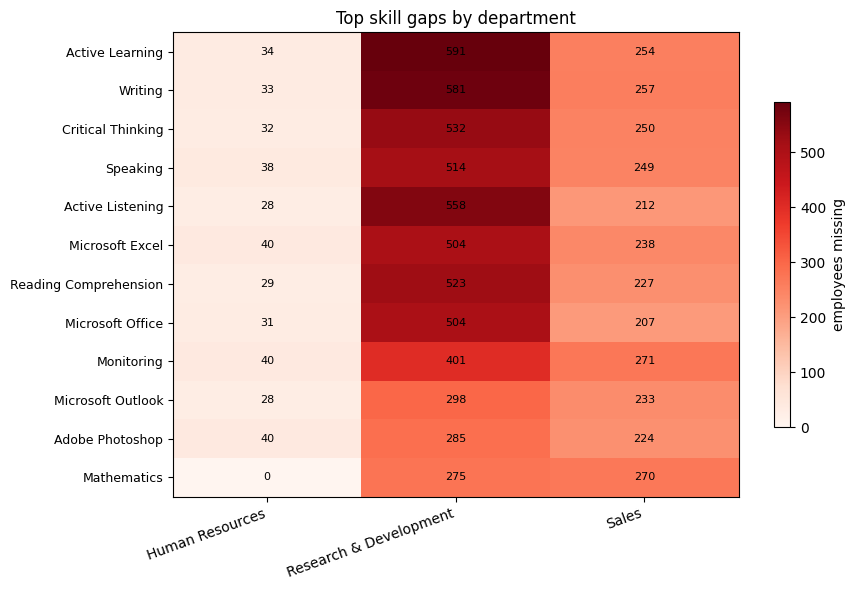

In [10]:
by_department = (gaps.groupby(["Department", "MissingSkill"]).size()
                 .rename("EmployeesMissing").reset_index())
pivot = (by_department.pivot(index="MissingSkill", columns="Department",
                             values="EmployeesMissing")
         .fillna(0).astype(int))
pivot = pivot.loc[org.head(12)["MissingSkill"]]

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(pivot.values, cmap="Reds", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=20, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, pivot.values[i, j], ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.7, label="employees missing")
ax.set_title("Top skill gaps by department")
plt.tight_layout()
plt.show()

## A note on interpreting these totals

The mechanism is real; the headcounts are not measurements. Which employee holds
which skill is synthesised (notebook 12), so "879 employees are missing Active
Learning" demonstrates that the roll-up works - it is not a finding about a real
workforce. Point a real skills inventory at
`data/raw/employee_current_skills.csv` and these same numbers become real.

In [11]:
org.to_csv(PROCESSED_FILES["org_skill_gaps"], index=False)
print(f"written: {PROCESSED_FILES['org_skill_gaps'].name}")
print(f"\nSeverity per the build notes : {dict(org['Severity'].value_counts())}")
print(f"Severity, proportional        : {dict(org['SeverityRelative'].value_counts())}")

written: organization_skill_gaps.csv

Severity per the build notes : {'HIGH': np.int64(36), 'MEDIUM': np.int64(11), 'LOW': np.int64(5)}
Severity, proportional        : {'LOW': np.int64(35), 'HIGH': np.int64(9), 'MEDIUM': np.int64(8)}
